# Test ode solver + furier transform

In [1]:
import os, argparse, time
import matplotlib.pyplot as plt
import numpy as np
from plotting import new_figure, save_figure
from ode.utils import load_from_config
from scipy.constants import c as c_cnst
from scipy import interpolate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


data = "GW_BIRME"
#data_dir = "data"
results_dir = "results"

theta = 45.0
phi = 0.0
Q = 2.19e5 

Ns = 250
geometry = "cylindrical"         # "rectangular", "cylindrical", "spherical"

modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
]

def build_file_path(m, geometry, theta, phi, data, results_dir, filename="amplitude_package.npz", base_path="."):
    mode_ind_str = ",".join(map(str, m["mode_ind"]))
    dir_name1 = f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}_Ns={Ns}'
    dir_name2 = f"DATA_{data}"
    return Path(base_path) / results_dir / dir_name1 / dir_name2 / filename

loaded_modes = {}


mode = [{"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)}]


fpath_1 = build_file_path(mode[0], geometry, theta, phi, data, results_dir=results_dir, filename="amplitude_package.npz", base_path=".")
fpath_RHS_1 = build_file_path(mode[0], geometry, theta, phi, data, results_dir=results_dir, filename=f"RHS_{geometry}_{mode[0]['mode_fam']}{mode[0]['mode_par']}_{','.join(map(str, mode[0]['mode_ind']))}_{data}.npz", base_path=".")

# loaded_modes["TMb_010"] = {
#     "results_dir": results_dir,
#     "fpath": fpath_1,
#     "data": np.load(fpath_1),
# }

loaded_modes["TMb_010_RHS"] = {
    "results_dir": results_dir,
    "fpath": fpath_RHS_1,
    "data": np.load(fpath_RHS_1),
}

for key, val in loaded_modes.items():
    print(f"Loaded {key} from {val['fpath']}")

d = loaded_modes["TMb_010_RHS"]["data"]

t = d["t"] if "t" in d.files else d["ts"]
rhs = d["RHS"]
ts = d["ts"]
pre_rhs = d["preRHS"] if "preRHS" in d.files else d["pre_RHS"]



m = mode[0]
mode_ind_str = ",".join(map(str, m["mode_ind"]))
run_dir = os.path.join(
    results_dir,
    f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}_Ns={Ns}'
)
omega, _ = load_from_config(run_dir)



Loaded TMb_010_RHS from results/cylindrical_TMb_0,1,0_theta=45.0_phi=0.0_Ns=250/DATA_GW_BIRME/RHS_cylindrical_TMb_0,1,0_GW_BIRME.npz


In [2]:



# #separate result in 2 blocks: orginal one + extended; 
# #first one calculate with ode solver
# #second one I want to calculate furier transform and differential equation for free block analitically





In [3]:
from ode.utils import (
    load_rhs, save_amplitude, extend_rhs, compute_b, compute_U,
    load_from_config, taper_signal,
    apply_onset_smoothing,
)
from ode.solver import solve_mode_amplitude
import numpy as np

# ── RHS setup (unchanged) ────────────────────────────────────────────────────
extend = 5.0
Q = 1e5

RHS = rhs

RHS_taper = taper_signal(RHS)
ts, RHS, _ = apply_onset_smoothing(ts, RHS_taper, n_periods=3)
ts_ext, RHS_ext, RHS_fn = extend_rhs(ts, RHS, extend)

# ── 1. Numerical solve over original ts only ─────────────────────────────────
result = solve_mode_amplitude(
    ts=ts,          # <-- original ts, not ts_ext
    RHS_fn=RHS_fn,
    omega=omega, Q=Q,
)
c_numerical  = result['c']    # shape: (len(ts),)
cD_numerical = result['cD']   # shape: (len(ts),)

# ── 2. Snapshot state at t0 (end of driven phase) ────────────────────────────
t0   = ts[-1]
c0   = c_numerical[-1]        # c_n(t0)
cD0  = cD_numerical[-1]       # c_dot_n(t0)

# ── 3. Analytical free-decay parameters ──────────────────────────────────────
alpha   = omega / (2.0 * Q)                        # damping rate
omega_d = omega * np.sqrt(1.0 - 1.0 / (4.0 * Q**2))  # damped frequency

A_n =  c0
B_n = (cD0 + alpha * c0) / omega_d

# ── 4. Evaluate analytical solution over the extended tail ───────────────────
ts_tail = ts_ext[len(ts):]    # time points in the free-decay region
tau     = ts_tail - t0        # shift to zero

c_analytical = np.exp(-alpha * tau) * (
    A_n * np.cos(omega_d * tau) +
    B_n * np.sin(omega_d * tau)
)

# ── 5. Stitch full solution together ─────────────────────────────────────────
c_full    = np.concatenate([c_numerical,  c_analytical])
ts_full   = ts_ext   # same length as c_full now


In [4]:

# ── 6. Reference: old full numerical solve (for comparison plot) ─────────────
result_ref = solve_mode_amplitude(
    ts=ts_ext, RHS_fn=RHS_fn,
    omega=omega, Q=Q,
)
c_ref = result_ref['c']

/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_93338/524393678.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/miniconda3/envs/cavity-response/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


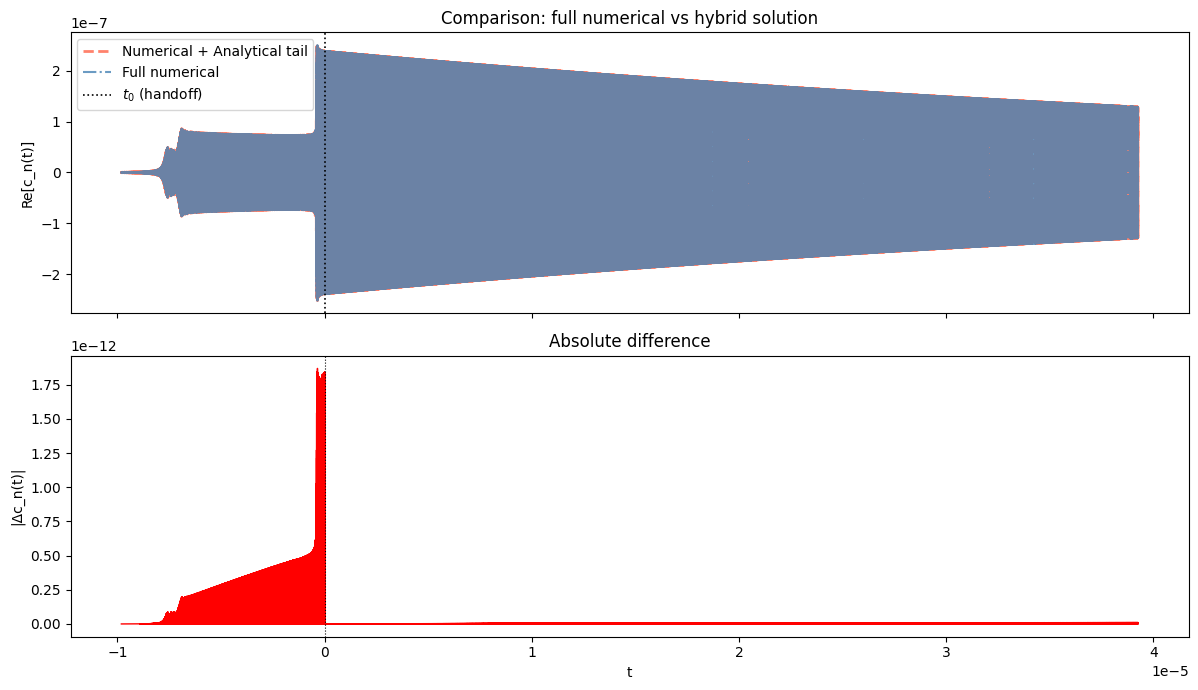

In [5]:
# ── 7. Plot comparison ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(ts_full, c_full.real, lw=2.0, color='tomato',  linestyle='--',  alpha=0.8, label='Numerical + Analytical tail')
ax.plot(ts_full, c_ref.real,  lw=1.5, color='steelblue',     alpha=0.8, linestyle = '-.', label='Full numerical')
ax.axvline(t0, color='k', linestyle=':', lw=1.2, label=f'$t_0$ (handoff)')
ax.set_ylabel('Re[c_n(t)]')
ax.legend()
ax.set_title('Comparison: full numerical vs hybrid solution')

ax = axes[1]
ax.plot(ts_full, np.abs(c_ref - c_full), lw=1.0, color='red')
ax.axvline(t0, color='k', linestyle=':', lw=0.8)
ax.set_ylabel('|Δc_n(t)|')
ax.set_xlabel('t')
ax.set_title('Absolute difference')

plt.tight_layout()
plt.show()

/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_93338/2656435171.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


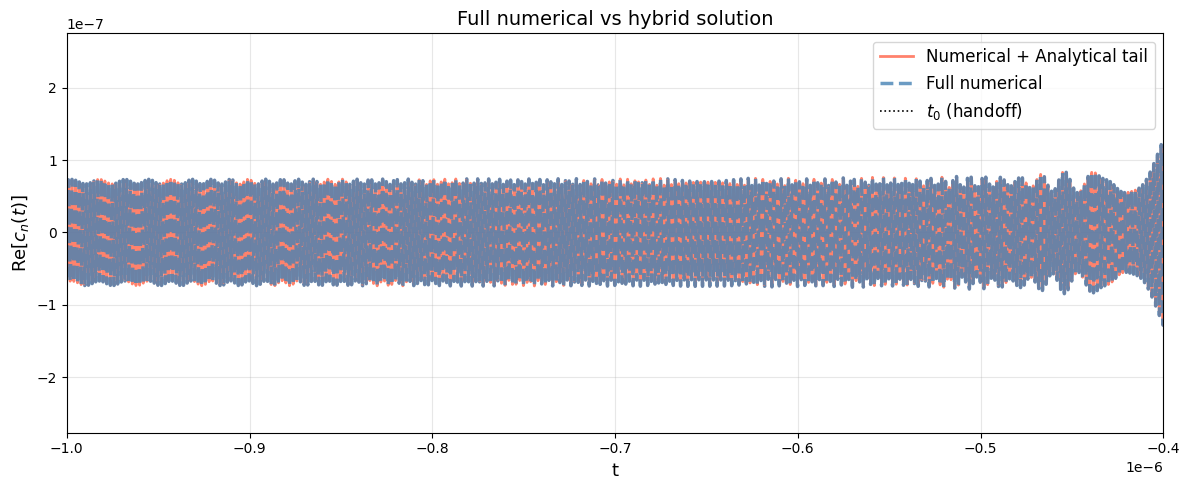

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

# ax.plot(ts_full, c_ref.real,  lw=1.5, color='steelblue', label='Full numerical')
# ax.plot(ts_full, c_full.real, lw=1.5, color='tomato',  label='Numerical + Analytical tail')

ax.plot(ts_full, c_full.real, lw=2.0, color='tomato',  alpha=0.8, label='Numerical + Analytical tail')
ax.plot(ts_full, c_ref.real,  lw=2.5, color='steelblue',  linestyle='--',   alpha=0.8, label='Full numerical')
ax.axvline(t0, color='k', linestyle=':', lw=1.2, label=f'$t_0$ (handoff)')

ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('Re[$c_n(t)$]', fontsize=13)
ax.set_title('Full numerical vs hybrid solution', fontsize=14)
ax.set_xlim(-0.1*10**-5, -0.04*10**-5)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Should be zero or tiny if the tail is the issue
print(np.max(np.abs(c_ref[len(ts):] - c_analytical)))  # tail difference

# This is what's showing up in your plot
print(np.max(np.abs(c_ref[:len(ts)] - c_numerical)))   # driven part difference

1.0130928618849554e-14
1.8697370242564114e-12
